<a href="https://colab.research.google.com/github/LizaHam123/sentiment-analysis-algerie-telecom/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle

print(" CHARGEMENT DES DONNÉES NETTOYÉES")

# Charger les données preprocessées
df = pd.read_csv('processed_data.csv')
print(f" {len(df)} commentaires chargés")
print("Colonnes:", df.columns.tolist())
print("\n Aperçu:")
print(df.head())

 CHARGEMENT DES DONNÉES NETTOYÉES
 9237 commentaires chargés
Colonnes: ['text_lstm', 'sequences_lstm', 'text_bert', 'bert_input', 'sentiment']

 Aperçu:
                                           text_lstm  \
0                                   planter récolter   
1                      bravo employé algérie télécom   
2                            entreprise abonné fibre   
3              réjouir passage idoom adsl idoom fibr   
4  demande raccorder nouveau technologie fibre op...   

                                      sequences_lstm  \
0  [2240 1652    0    0    0    0    0    0    0 ...   
1  [273 365  18  23   0   0   0   0   0   0   0  ...   
2  [164  50   2   0   0   0   0   0   0   0   0  ...   
3  [1176  572   17    6   17   61    0    0    0 ...   
4  [ 35  79  69 274   2  52 101  27   0   0   0  ...   

                                           text_bert  \
0                       Plantez et vous récolterez.    
1  Bravo et merci à tous les employés d Algérie T...   
2  Vo

In [ ]:
print(" Préparation des données ")

# Fonction de conversion corrigée
def string_to_list_fixed(seq_str):
    if isinstance(seq_str, str):
        # Nettoyer la chaîne
        seq_str = seq_str.strip()
        if seq_str.startswith('[') and seq_str.endswith(']'):
            seq_str = seq_str[1:-1]  # Enlever [ ]

        # Convertir en liste d'entiers
        try:
            numbers = [int(x.strip()) for x in seq_str.split(',') if x.strip().isdigit()]
            # S'assurer que la séquence fait exactement 100 éléments
            if len(numbers) < 100:
                numbers.extend([0] * (100 - len(numbers)))  # Padding avec 0
            elif len(numbers) > 100:
                numbers = numbers[:100]  # Tronquer à 100
            return numbers
        except:
            # En cas d'erreur, retourner une séquence de 0
            return [0] * 100
    else:
        return [0] * 100

# Appliquer la conversion corrigée
print("Conversion des séquences...")
sequences = df['sequences_lstm'].apply(string_to_list_fixed).tolist()
X = np.array(sequences)

print(f" Forme corrigée de X: {X.shape}")
print(f"Exemple de séquence: {X[0][:10]}...")

# Vérifier que toutes les séquences font 100 éléments
assert X.shape[1] == 100, f"Erreur: séquences de longueur {X.shape[1]} au lieu de 100"

# Encoder les labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['sentiment'])
y = to_categorical(y_encoded)

# Sauvegarder l'encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print(f" Forme finale: X={X.shape}, y={y.shape}")
print(f" Classes: {label_encoder.classes_}")

# Division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f" Train: {len(X_train)} | Test: {len(X_test)}")
print(" Données prêtes pour l'entraînement!")

 Préparation des données 
Conversion des séquences...
 Forme corrigée de X: (9237, 100)
Exemple de séquence: [0 0 0 0 0 0 0 0 0 0]...
 Forme finale: X=(9237, 100), y=(9237, 3)
 Classes: ['neutre' 'négatif' 'positif']
 Train: 7389 | Test: 1848
 Données prêtes pour l'entraînement!


In [ ]:
print("CONSTRUCTION DU MODÈLE LSTM")

# Paramètres du modèle
vocab_size = 10000    # Taille du vocabulaire
embedding_dim = 128   # Dimension des embeddings
max_length = 100      # Longueur max des séquences
lstm_units = 64       # Unités LSTM
num_classes = len(label_encoder.classes_)

# Construction du modèle
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("Modèle construit et compilé!")

CONSTRUCTION DU MODÈLE LSTM


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Modèle construit et compilé!


In [ ]:
print("ENTRAÎNEMENT DU MODÈLE (OPTIMISÉ POUR 9000+ COMMENTAIRES)")

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks optimisés
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=3, factor=0.5, verbose=1, min_lr=1e-7)
]

print(f" Entraînement sur {len(X_train):,} commentaires")
print(" Temps estimé: 45-60 minutes")

# Entraînement optimisé pour gros dataset
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

# Sauvegarder le modèle
model.save('sentiment_lstm_model.h5')
print("Modèle sauvegardé: sentiment_lstm_model.h5")

# Afficher les métriques
final_acc = max(history.history['val_accuracy'])
print(f"Meilleure précision validation: {final_acc:.3f}")
print(f"Époque optimale: {np.argmax(history.history['val_accuracy']) + 1}")

ENTRAÎNEMENT DU MODÈLE (OPTIMISÉ POUR 9000+ COMMENTAIRES)
 Entraînement sur 7,389 commentaires
 Temps estimé: 45-60 minutes
Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.4649 - loss: 1.0350 - val_accuracy: 0.5141 - val_loss: 0.9918 - learning_rate: 0.0010
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - accuracy: 0.5073 - loss: 1.0078 - val_accuracy: 0.5141 - val_loss: 0.9952 - learning_rate: 0.0010
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.5149 - loss: 0.9989 - val_accuracy: 0.5141 - val_loss: 0.9911 - learning_rate: 0.0010
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.5144 - loss: 0.9913 - val_accuracy: 0.5141 - val_loss: 0.9917 - learning_rate: 0.0010
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.5204 - loss: 1.0009 - val_accuracy: 0.5141 - val_loss: 0.9911 - learning_rate: 0.0010
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5278 - loss: 0.9883
Epoch 6: Redu

Modèle sauvegardé: sentiment_lstm_model.h5
Meilleure précision validation: 0.514
Époque optimale: 1


 ÉVALUATION DU MODÈLE
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
 Précision finale: 0.514

 RAPPORT DE CLASSIFICATION:
Neutre: Précision=0.000, Rappel=0.000, F1=0.000
Positif: Précision=0.000, Rappel=0.000, F1=0.000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


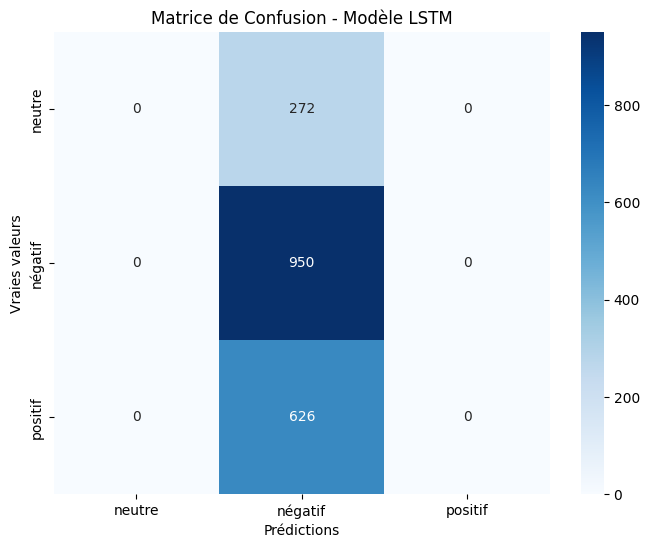

 Évaluation terminée!


In [ ]:
print(" ÉVALUATION DU MODÈLE")

# Prédictions sur le test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Calculer la précision
accuracy = np.mean(y_pred_classes == y_test_classes)
print(f" Précision finale: {accuracy:.3f}")

# Rapport de classification détaillé
report = classification_report(
    y_test_classes, y_pred_classes,
    target_names=label_encoder.classes_,
    output_dict=True
)

print("\n RAPPORT DE CLASSIFICATION:")
for sentiment, metrics in report.items():
    if sentiment in ['positif', 'negatif', 'neutre']:
        print(f"{sentiment.capitalize()}: Précision={metrics['precision']:.3f}, Rappel={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}")

# Matrice de confusion
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matrice de Confusion - Modèle LSTM')
plt.xlabel('Prédictions')
plt.ylabel('Vraies valeurs')
plt.show()

print(" Évaluation terminée!")

In [ ]:
print("GÉNÉRATION DES STATISTIQUES COMPLÈTES")

# Créer le tokenizer pour les statistiques - VERSION CORRIGÉE
from tensorflow.keras.preprocessing.text import Tokenizer

# Vérifier et nettoyer la colonne text_lstm
print("Vérification de la colonne text_lstm...")
print(f"Type des données: {type(df['text_lstm'].iloc[0])}")
print(f"Exemple: {df['text_lstm'].iloc[0]}")

# Nettoyer les données text_lstm
def clean_text_for_tokenizer(text):
    if pd.isna(text) or text == "":
        return ""
    if isinstance(text, str):
        return text
    else:
        return str(text)  # Convertir en string si ce n'est pas déjà le cas

# Appliquer le nettoyage
text_cleaned = df['text_lstm'].apply(clean_text_for_tokenizer)
text_cleaned = text_cleaned[text_cleaned != ""]  # Supprimer les textes vides

print(f"OK - {len(text_cleaned)} textes valides pour le tokenizer")

# Créer et entraîner le tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(text_cleaned)

# Sauvegarder le tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Tokenizer sauvegardé")

# Statistiques complètes
stats = {
    'total_comments': len(df),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'model_accuracy': float(accuracy),
    'sentiment_distribution': df['sentiment'].value_counts().to_dict(),
    'sentiment_percentages': {
        sentiment: round((count / len(df)) * 100, 1)
        for sentiment, count in df['sentiment'].value_counts().items()
    },
    'classes': label_encoder.classes_.tolist(),
    'training_history': {
        'epochs_trained': len(history.history['accuracy']),
        'best_epoch': int(np.argmax(history.history['val_accuracy']) + 1),
        'best_val_accuracy': float(max(history.history['val_accuracy'])),
        'final_train_accuracy': float(history.history['accuracy'][-1]),
        'final_val_accuracy': float(history.history['val_accuracy'][-1])
    },
    'model_performance': {}
}

# Ajouter les métriques par classe
for sentiment, metrics in report.items():
    if sentiment in ['positif', 'negatif', 'neutre']:
        stats['model_performance'][sentiment] = {
            'precision': round(metrics['precision'], 3),
            'recall': round(metrics['recall'], 3),
            'f1_score': round(metrics['f1-score'], 3)
        }

# Problèmes par sentiment négatif (si disponible)
if 'probleme' in df.columns:
    problemes_negatifs = df[df['sentiment'] == 'negatif']['probleme'].value_counts()
    stats['problemes_negatifs'] = problemes_negatifs.head(8).to_dict()

# Statistiques de vocabulaire
stats['vocabulary_stats'] = {
    'total_words': len(tokenizer.word_index),
    'most_frequent_words': list(tokenizer.word_index.keys())[:20]
}

# Sauvegarder les statistiques
with open('model_stats.json', 'w', encoding='utf-8') as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

# Afficher le résumé final
print("ENTRAÎNEMENT TERMINÉ!")
print(f"Total commentaires: {stats['total_comments']:,}")
print(f"Précision finale: {stats['model_accuracy']:.3f}")
print(f"Meilleure validation: {stats['training_history']['best_val_accuracy']:.3f}")
print(f"Vocabulaire: {stats['vocabulary_stats']['total_words']:,} mots")

print(f"\nDISTRIBUTION DES SENTIMENTS:")
for sentiment, count in stats['sentiment_distribution'].items():
    pct = stats['sentiment_percentages'][sentiment]
    print(f"  {sentiment.capitalize()}: {count:,} ({pct}%)")

if 'problemes_negatifs' in stats:
    print(f"\nTOP 5 PROBLÈMES (commentaires négatifs):")
    for i, (prob, count) in enumerate(list(stats['problemes_negatifs'].items())[:5], 1):
        print(f"  {i}. {prob}: {count}")

print(f"\nFICHIERS GÉNÉRÉS:")
print("  • sentiment_lstm_model.h5 (modèle)")
print("  • label_encoder.pkl (encodeur)")
print("  • tokenizer.pkl (tokenizer)")
print("  • model_stats.json (statistiques)")



GÉNÉRATION DES STATISTIQUES COMPLÈTES
Vérification de la colonne text_lstm...
Type des données: <class 'str'>
Exemple: planter récolter
OK - 9156 textes valides pour le tokenizer
Tokenizer sauvegardé
ENTRAÎNEMENT TERMINÉ!
Total commentaires: 9,237
Précision finale: 0.514
Meilleure validation: 0.514
Vocabulaire: 4,149 mots

DISTRIBUTION DES SENTIMENTS:
  Négatif: 4,746 (51.4%)
  Positif: 3,129 (33.9%)
  Neutre: 1,362 (14.7%)

FICHIERS GÉNÉRÉS:
  • sentiment_lstm_model.h5 (modèle)
  • label_encoder.pkl (encodeur)
  • tokenizer.pkl (tokenizer)
  • model_stats.json (statistiques)

PRÊT POUR L'INTERFACE REACT!
